# DNA Storage Quality Index (DSQI)

## End-to-end PySpark / Google Colab implementation

This master notebook implements the evidence-first workflow in the supplied project plan. It uses the **public Clustered Nanopore Reads (CNR) dataset** as the default executable benchmark because the public DNAformer repository contains a small sample but states that its full experimental datasets are shared on request. The notebook also downloads and inspects the DNAformer sample when available and provides an optional external-validation interface.

The default target is the **observed normalized edit distance** between each CNR noisy read and its released center/reference sequence. This is a measurable sequencing-error proxy, not a simulated label. The notebook deliberately does not assume that GC content, homopolymers, or entropy are good or bad; the direction and magnitude of relationships are estimated from the data.

> **Colab execution note.** Spark runs in local mode on the Colab VM. This demonstrates SparkSession, SparkContext, RDD, DataFrame, SQL, MLlib, and distributed-style transformations, but it is not a multi-node production cluster. All claims should be interpreted within the selected dataset and sample size.

### Notebook map

| Section | Purpose |
|---|---|
| 01–03 | Environment, acquisition, inspection |
| 04–07 | RDD, Pandas, DataFrame, cleaning |
| 08–12 | DNA features, SQL, EDA, statistics |
| 13–16 | MLlib regression, classification, clustering, importance |
| 17 | Similarity graph and GraphX-compatible design |
| 18–21 | DSQI construction, validation, external validation, dashboard |
| 22 | Reproducibility manifest and final conclusions |

## 01. Environment setup and reproducibility

The next cell installs only the packages needed by this notebook. Re-running it in an already configured runtime is safe. The seed is kept fixed so that the train/test split, clustering, and sampled graph are reproducible.

In [ ]:
# Colab setup. Run once per fresh runtime.
# Dependencies already installed for local smoke test

import os, sys, json, math, re, hashlib, platform, shutil, subprocess, itertools, urllib.request
from pathlib import Path
from collections import Counter, defaultdict

os.environ['SPARK_LOCAL_IP'] = '127.0.0.1'
os.environ['PYSPARK_PYTHON'] = sys.executable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy import stats

from pyspark.sql import SparkSession, Row, functions as F, types as T
from pyspark.sql.window import Window
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression, RandomForestRegressor
from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier, RandomForestClassifier
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import RegressionEvaluator, MulticlassClassificationEvaluator, BinaryClassificationEvaluator

SEED = 4262
np.random.seed(SEED)

PROJECT_ROOT = Path('/content/drive/MyDrive/DSQI_Project')
USE_DRIVE = False  # Set True if you want persistent files in Google Drive.
if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
else:
    PROJECT_ROOT = Path('/home/ubuntu/DSQI_smoke')

for p in [PROJECT_ROOT/'data/raw', PROJECT_ROOT/'data/processed', PROJECT_ROOT/'data/external',
          PROJECT_ROOT/'models', PROJECT_ROOT/'outputs/figures', PROJECT_ROOT/'outputs/tables',
          PROJECT_ROOT/'outputs/predictions', PROJECT_ROOT/'checkpoints', PROJECT_ROOT/'reports']:
    p.mkdir(parents=True, exist_ok=True)

spark = (SparkSession.builder
         .appName('DNA-Storage-Quality-Index')
         .master('local[*]')
         .config('spark.sql.shuffle.partitions', '8')
         .config('spark.driver.memory', '4g')
         .getOrCreate())
sc = spark.sparkContext
spark.sparkContext.setLogLevel('WARN')

print('Python:', sys.version.split()[0])
print('PySpark:', spark.version)
print('Spark master:', sc.master)
print('Spark application:', spark.sparkContext.appName)
print('SparkSession:', spark)
print('SparkContext:', sc)
try:
    print('Java:', subprocess.check_output(['java', '-version'], stderr=subprocess.STDOUT, text=True).splitlines()[0])
except Exception as e:
    print('Java version check unavailable:', e)
print('CPU count:', os.cpu_count())
print('Disk free GB:', round(shutil.disk_usage(PROJECT_ROOT).free / 1e9, 2))

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/08/24 07:28:19 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Python: 3.12.3
PySpark: 3.5.1
Spark master: local[*]
Spark application: DNA-Storage-Quality-Index
SparkSession: <pyspark.sql.session.SparkSession object at 0x7f95d3ddcf80>
SparkContext: <SparkContext master=local[*] appName=DNA-Storage-Quality-Index>
Java: openjdk version "21.0.11" 2026-04-21
CPU count: 6
Disk free GB: 32.12


## 02. Dataset acquisition

The default public benchmark is the Microsoft CNR dataset. Its `Centers.txt` file contains reference sequences and `Clusters.txt` contains noisy Oxford Nanopore reads grouped in the same order as the centers. The notebook reads a bounded number of clusters by default so that it remains comfortable on Colab.

The DNAformer repository is also inspected through its public raw sample files. Because the repository does not publish the full experimental dataset, DNAformer is treated as a documented sample/source rather than as an invented substitute for observed labels.

In [ ]:
import requests

CNR_URLS = {
    'centers': 'https://raw.githubusercontent.com/microsoft/clustered-nanopore-reads-dataset/main/Centers.txt',
    'clusters': 'https://raw.githubusercontent.com/microsoft/clustered-nanopore-reads-dataset/main/Clusters.txt',
}
DNAFORMER_URLS = {
    'fastq_1': 'https://raw.githubusercontent.com/itaiorr/Deep-DNA-based-storage/main/DeepEncoderDecoder/data/fastq_runid_f9875c0bb5171f8bae2f76aa5d9ac39431889861_1_0.fastq',
    'design': 'https://raw.githubusercontent.com/itaiorr/Deep-DNA-based-storage/main/DeepEncoderDecoder/deep_design.csv',
}

RAW_DIR = PROJECT_ROOT/'data/raw'
CENTERS_PATH = RAW_DIR/'cnr_Centers.txt'
CLUSTERS_PATH = RAW_DIR/'cnr_Clusters.txt'
DNAFORMER_FASTQ_PATH = RAW_DIR/'dnaformer_sample.fastq'
DNAFORMER_DESIGN_PATH = RAW_DIR/'dnaformer_deep_design.csv'


def download(url, path, chunk_size=1024*1024):
    path = Path(path)
    if path.exists() and path.stat().st_size > 0:
        return path
    r = requests.get(url, stream=True, timeout=120)
    r.raise_for_status()
    with open(path, 'wb') as f:
        for chunk in r.iter_content(chunk_size=chunk_size):
            if chunk:
                f.write(chunk)
    return path

for key, url in CNR_URLS.items():
    download(url, {'centers': CENTERS_PATH, 'clusters': CLUSTERS_PATH}[key])
for key, url in DNAFORMER_URLS.items():
    try:
        download(url, {'fastq_1': DNAFORMER_FASTQ_PATH, 'design': DNAFORMER_DESIGN_PATH}[key])
    except Exception as e:
        print(f'Optional DNAformer file unavailable ({key}): {e}')

def sha256(path):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for block in iter(lambda: f.read(1024*1024), b''):
            h.update(block)
    return h.hexdigest()

manifest_rows = []
for path, source, purpose in [
    (CENTERS_PATH, 'Microsoft CNR GitHub', 'reference sequences'),
    (CLUSTERS_PATH, 'Microsoft CNR GitHub', 'observed noisy reads'),
    (DNAFORMER_FASTQ_PATH, 'DNAformer GitHub', 'sample acquisition/inspection'),
    (DNAFORMER_DESIGN_PATH, 'DNAformer GitHub', 'sample design inspection'),
]:
    if Path(path).exists():
        manifest_rows.append({'file': str(path), 'source': source, 'size_bytes': path.stat().st_size,
                              'purpose': purpose, 'sha256': sha256(path)})
manifest_df = pd.DataFrame(manifest_rows)
manifest_df.to_csv(PROJECT_ROOT/'outputs/tables/dataset_manifest.csv', index=False)
manifest_df

,file,source,size_bytes,purpose,sha256
0,/home/ubuntu/DSQI_smoke/data/raw/cnr_Centers.txt,Microsoft CNR GitHub,1120000,reference sequences,b70e723ef0d83a88f7b3e483b932b0279628a0eae39cb4...
1,/home/ubuntu/DSQI_smoke/data/raw/cnr_Clusters.txt,Microsoft CNR GitHub,30452518,observed noisy reads,7c2e27b497762ed3bb01a2d27ed09ca2291d590a0a7534...
2,/home/ubuntu/DSQI_smoke/data/raw/dnaformer_sam...,DNAformer GitHub,2108941,sample acquisition/inspection,26daf86e61a9b2291a4d8c34bb081ae9560ceeefcedc88...
3,/home/ubuntu/DSQI_smoke/data/raw/dnaformer_dee...,DNAformer GitHub,16940017,sample design inspection,14a392c3fe36a72e74f49a48c07578738d61032fd84cbd...


In [ ]:
# Parse the CNR release. Empty clusters are retained as zero-read reference records.
MAX_CENTERS = 200      # Increase after validating runtime and memory.
MAX_READS_PER_CENTER = 50

centers = []
with open(CENTERS_PATH) as f:
    for i, line in enumerate(f):
        if i >= MAX_CENTERS:
            break
        seq = line.strip().upper()
        centers.append(seq)

clusters = [[] for _ in centers]
cluster_idx = -1
with open(CLUSTERS_PATH) as f:
    for raw in f:
        line = raw.strip().upper()
        if line.startswith('='):
            cluster_idx += 1
            if cluster_idx >= len(clusters):
                break
            continue
        if cluster_idx >= 0 and cluster_idx < len(clusters) and line and set(line) <= set('ACGT'):
            if len(clusters[cluster_idx]) < MAX_READS_PER_CENTER:
                clusters[cluster_idx].append(line)

records = []
for i, reference in enumerate(centers):
    records.append((f'CNR_{i:05d}', reference, clusters[i], 'Oxford Nanopore'))

print('Reference records:', len(records))
print('References with at least one read:', sum(bool(x[2]) for x in records))
print('Total retained reads:', sum(len(x[2]) for x in records))
print('Reference length distribution:', Counter(map(len, centers)).most_common(5))

# Inspect the DNAformer sample as raw FASTQ records, without treating it as labeled error data.
def read_fastq(path, max_records=5):
    out = []
    if not Path(path).exists():
        return out
    with open(path) as f:
        while len(out) < max_records:
            header = f.readline().strip()
            seq = f.readline().strip()
            plus = f.readline().strip()
            qual = f.readline().strip()
            if not header or not seq:
                break
            out.append({'header': header, 'sequence': seq, 'quality_length': len(qual)})
    return out

dnaformer_sample = pd.DataFrame(read_fastq(DNAFORMER_FASTQ_PATH, max_records=5))
print('DNAformer sample preview:')
display(dnaformer_sample)

Reference records: 200
References with at least one read: 200
Total retained reads: 5021
Reference length distribution: [(110, 200)]
DNAformer sample preview:


,header,sequence,quality_length
0,@c146fb1b-1bea-4101-a17c-5a7a664cf4f2 runid=f9...,AACATCCAGCTTGTACTTCGTTCAGTTGCATGCTTCGTCGGCAGCG...,246
1,@b9810eb6-40e7-4707-a4ce-78d1d2856041 runid=f9...,ACCTCCTTGTACTTCGTTCAGTTACGTATTGCTGTCTCGTGGGCTC...,250
2,@215974a3-24e7-42db-ae47-ed7792fd6212 runid=f9...,TTGTACTTCGTTCAGTTACGTATTGCTGTCGGCAGCGTCAGATGTG...,239
3,@cf266d48-c457-42e8-b0ac-355218367a3b runid=f9...,AGCGTAGCCCCGTTCAGTTACGTATTGCTTCGTCGGCAGCGTCAGA...,245
4,@d57635c2-aa09-45af-8cd9-89854a76915a runid=f9...,AACATTGCTGGTTCAGTTGACAATGTGCGACCAAGCGGCGTCAGAT...,237


### Data provenance and limitation

The CNR repository documents that centers and clusters correspond by order, and that reads were generated from DNA synthesized by Twist Bioscience and sequenced using Oxford Nanopore MinION. Its 2024 note also warns that the released center collection has long-range dependencies and that some clusters may be malformed. Those facts are recorded here because they affect interpretation. The notebook therefore reports the selected subset, checksum, seeds, and sample-size limits instead of presenting the results as universal DNA-storage laws.

## 03. Raw inspection and SparkSession versus SparkContext

`SparkSession` is the modern entry point for DataFrames and SQL. `SparkContext` exposes the lower-level RDD API. The next cells intentionally use both, satisfying the project requirement and making the data flow explicit.

In [ ]:
# RDD inspection over the raw reference file.
raw_centers_rdd = sc.textFile(str(CENTERS_PATH))
print('Raw center line count:', raw_centers_rdd.count())
print('First five raw centers:', raw_centers_rdd.take(5))

center_map_rdd = (raw_centers_rdd
                  .zipWithIndex()
                  .map(lambda x: (f'CNR_{x[1]:05d}', x[0].strip().upper()))
                  .filter(lambda x: bool(x[1]))
                  .filter(lambda x: set(x[1]) <= set('ACGT'))
                  .filter(lambda x: x[1] in set(centers))
                  .distinct())
print('Validated distinct reference pairs:', center_map_rdd.count())

Raw center line count: 10000
First five raw centers: ['ACCATAATGCGTGGGGCCGACCTCGGAATGCGGTCTCCATGCGCGTTTCCTCCAACCTAAGGTAGCCTGTAGTTCATTGGACCTCTGATGGCGCTTATAGAAACCGGGAA', 'TCGAAGCAGTAGGGCCTACCAAATAGGTTGGTCCTCCGTTGTATCTAAGGATTGAGTTTACCTGGCTTACACGGCAGGTACCGCCAATCTCGTCCGGCTCCGCGGCATCC', 'AGTTAACGTCCCACGGCGAGGCACTCTTGATCCCCACCTTCAAGAGGTGTACCGGATCATGGAGAACAAGCATACGTCGCACGCACACCATTGGACGGCGAGTGCCGAGT', 'GCCCAAGGGTACGCCCGCAGCGACGCAATTGGCGGAGTAAGCGCGTGTCACACAGCCGACCGCTCGTGCTACGCCTCCTCCTCGCTCCACGATGGAAAAGCGAGCCGGAG', 'GCACTGATGTAACTCATGGTACATCCGTCGCTGAGCGCCATTTTGTTACGTCACCTGGCTGGAACGTCGTCCACAGGAAACATCGGCCCACGCCGGTACTCCATACGCTT']


Validated distinct reference pairs: 200


## 04. Required RDD transformations

The project plan asks for `map`, `filter`, `flatMap`, `reduceByKey`, `groupByKey`, and `distinct`. The example below demonstrates all six on the real CNR reference sample. `groupByKey` is shown for inspection only; aggregations should normally prefer `reduceByKey` to avoid unnecessary shuffling.

In [ ]:
# map(): (sequence_id, sequence)
parsed_rdd = raw_centers_rdd.zipWithIndex().map(lambda x: (f'CNR_{x[1]:05d}', x[0].strip().upper()))

# filter(): valid DNA strings only
valid_rdd = parsed_rdd.filter(lambda x: len(x[1]) > 0 and set(x[1]) <= set('ACGT'))

# distinct(): remove duplicate records
unique_rdd = valid_rdd.distinct()

K = 3
# flatMap(): emit (kmer, 1) for every k-mer in every valid sequence
kmer_pairs = unique_rdd.flatMap(lambda row: [(row[1][i:i+K], 1) for i in range(len(row[1]) - K + 1)])

# reduceByKey(): distributed k-mer counts
kmer_counts = kmer_pairs.reduceByKey(lambda a, b: a + b)
print('Most frequent 3-mers:', kmer_counts.takeOrdered(10, key=lambda x: -x[1]))

# groupByKey(): group sequence IDs by observed length for demonstration
length_groups = (unique_rdd.map(lambda x: (len(x[1]), x[0]))
                 .groupByKey()
                 .mapValues(lambda ids: list(ids)[:5]))
print('Length groups:', length_groups.collect())

# A small derived RDD for sample-only local inspection.
sample_pairs = unique_rdd.take(10)
sample_pd = pd.DataFrame(sample_pairs, columns=['sequence_id', 'sequence'])
sample_pd

Most frequent 3-mers: [('CAT', 17544), ('TAC', 17518), ('GCA', 17478), ('AGT', 17476), ('TTA', 17465), ('GGC', 17459), ('TCC', 17458), ('AAG', 17450), ('GTC', 17446), ('CGG', 17446)]


Length groups: [(110, ['CNR_00002', 'CNR_00003', 'CNR_00006', 'CNR_00009', 'CNR_00011'])]


,sequence_id,sequence
0,CNR_00002,AGTTAACGTCCCACGGCGAGGCACTCTTGATCCCCACCTTCAAGAG...
1,CNR_00003,GCCCAAGGGTACGCCCGCAGCGACGCAATTGGCGGAGTAAGCGCGT...
2,CNR_00006,CATTGGAGACTTCTAGCCGTGTCAGATTTTGGGATGAGCATTTGGT...
3,CNR_00009,AGTGCCGGTGGCACTCATTTACTGCCACCAAGGTTGCGGATACAAG...
4,CNR_00011,GATCTGACCGGGGGTCCGGTGCCGACGGAAGTTCTGCTCTGAGAAC...
5,CNR_00013,ATTAGTAATCTCGACCTGCCGCCGCTGCTCTCGTGAGCTATACCGG...
6,CNR_00014,ATACCGTAGCCCAGCGAAAACTCTGCCTCTGCGAACTATAATCTTC...
7,CNR_00016,ACATGAGACAAAGGAGACATATGCCGAGTTCATTAGGTGGCGCCAT...
8,CNR_00017,CGGTCTAGCTAAGCGACTGCCTAGTGTCTCATCTGGATTGTCCATC...
9,CNR_00018,GTGGCGACCAACTTCACTTAGATTGTCGGTCGCAGTGTTACTCGGT...


## 05. Feature engineering functions

Features are computed from the reference sequence and the observed error rate is computed from the released reads. GC deviation is measured from the empirical median GC content of the selected reference subset, rather than assuming that 50% GC is universally optimal. Shannon entropy uses the four-base alphabet and is measured in bits.

In [ ]:
BASES = 'ACGT'

def max_homopolymer(seq):
    if not seq:
        return 0
    best = cur = 1
    for a, b in zip(seq, seq[1:]):
        cur = cur + 1 if a == b else 1
        best = max(best, cur)
    return best

def shannon_entropy(seq):
    if not seq:
        return 0.0
    counts = Counter(seq)
    n = len(seq)
    return float(-sum((c/n) * math.log2(c/n) for c in counts.values() if c))

def kmer_unique_ratio(seq, k=3):
    total = max(len(seq) - k + 1, 0)
    return float(len(set(seq[i:i+k] for i in range(total))) / total) if total else 0.0

def repeat_ratio(seq, k=3):
    total = max(len(seq) - k + 1, 0)
    if not total:
        return 0.0
    counts = Counter(seq[i:i+k] for i in range(total))
    repeated = sum(c for c in counts.values() if c > 1)
    return float(repeated / total)

def levenshtein(a, b):
    # Memory-efficient normalized edit distance for short DNA strings.
    if a == b:
        return 0
    if len(a) < len(b):
        a, b = b, a
    prev = list(range(len(b) + 1))
    for i, ca in enumerate(a, 1):
        cur = [i]
        for j, cb in enumerate(b, 1):
            cur.append(min(cur[-1] + 1, prev[j] + 1, prev[j-1] + (ca != cb)))
        prev = cur
    return prev[-1]

def mean_normalized_error(reference, reads):
    if not reads:
        return None
    denom = max(len(reference), 1)
    return float(np.mean([levenshtein(reference, read) / denom for read in reads]))

reference_gc = float(np.mean([(s.count('G') + s.count('C')) / max(len(s), 1) for s in centers]))
print('Empirical reference GC target:', round(reference_gc, 4))

# Build feature rows from real references and real noisy reads.
feature_rows = []
for sequence_id, reference, reads, platform in records:
    gc = (reference.count('G') + reference.count('C')) / max(len(reference), 1)
    feature_rows.append({
        'sequence_id': sequence_id,
        'sequence': reference,
        'platform': platform,
        'length': int(len(reference)),
        'gc_content': float(gc),
        'gc_deviation': float(abs(gc - reference_gc)),
        'homopolymer_max': int(max_homopolymer(reference)),
        'entropy': float(shannon_entropy(reference)),
        'unique_kmer_ratio': float(kmer_unique_ratio(reference, 3)),
        'repeat_ratio': float(repeat_ratio(reference, 3)),
        'read_count': int(len(reads)),
        'error_rate': mean_normalized_error(reference, reads),
    })

feature_pd = pd.DataFrame(feature_rows)
feature_pd = feature_pd[feature_pd['error_rate'].notna()].copy()
print('Analytical rows with observed reads:', len(feature_pd))
display(feature_pd.head())

Empirical reference GC target: 0.5034


26/08/24 07:28:33 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


Analytical rows with observed reads: 200


,sequence_id,sequence,platform,length,gc_content,gc_deviation,homopolymer_max,entropy,unique_kmer_ratio,repeat_ratio,read_count,error_rate
0,CNR_00000,ACCATAATGCGTGGGGCCGACCTCGGAATGCGGTCTCCATGCGCGT...,Oxford Nanopore,110,0.545455,0.042091,4,1.993505,0.500000,0.787037,50,0.050909
1,CNR_00001,TCGAAGCAGTAGGGCCTACCAAATAGGTTGGTCCTCCGTTGTATCT...,Oxford Nanopore,110,0.554545,0.051182,3,1.987079,0.500000,0.796296,19,0.059809
2,CNR_00002,AGTTAACGTCCCACGGCGAGGCACTCTTGATCCCCACCTTCAAGAG...,Oxford Nanopore,110,0.572727,0.069364,4,1.972375,0.500000,0.805556,12,0.068939
3,CNR_00003,GCCCAAGGGTACGCCCGCAGCGACGCAATTGGCGGAGTAAGCGCGT...,Oxford Nanopore,110,0.663636,0.160273,4,1.904548,0.444444,0.833333,16,0.053409
4,CNR_00004,GCACTGATGTAACTCATGGTACATCCGTCGCTGAGCGCCATTTTGT...,Oxford Nanopore,110,0.554545,0.051182,4,1.981453,0.453704,0.833333,36,0.052020


## 06. Pandas → Spark DataFrame and cleaning

Only the bounded analytical subset is converted from Pandas to Spark because this notebook first parses the public CNR text release into reference-level records. In a larger deployment, the same feature-row contract can be written to Parquet in partitions and never collected to the driver.

In [ ]:
feature_schema = T.StructType([
    T.StructField('sequence_id', T.StringType(), False),
    T.StructField('sequence', T.StringType(), False),
    T.StructField('platform', T.StringType(), False),
    T.StructField('length', T.IntegerType(), False),
    T.StructField('gc_content', T.DoubleType(), False),
    T.StructField('gc_deviation', T.DoubleType(), False),
    T.StructField('homopolymer_max', T.IntegerType(), False),
    T.StructField('entropy', T.DoubleType(), False),
    T.StructField('unique_kmer_ratio', T.DoubleType(), False),
    T.StructField('repeat_ratio', T.DoubleType(), False),
    T.StructField('read_count', T.IntegerType(), False),
    T.StructField('error_rate', T.DoubleType(), False),
])

df = spark.createDataFrame(feature_pd.to_dict('records'), schema=feature_schema)

# Cleaning checks; outliers are not automatically deleted.
DNA_RE = '^[ACGT]+$'
clean_df = (df
    .filter(F.col('sequence').rlike(DNA_RE))
    .filter(F.col('length') > 0)
    .filter(F.col('error_rate').isNotNull())
    .dropDuplicates(['sequence_id'])
    .withColumn('error_rate', F.when(F.col('error_rate') >= 0, F.col('error_rate')).otherwise(F.lit(None)))
    .dropna(subset=['error_rate']))

print('Clean analytical rows:', clean_df.count())
clean_df.printSchema()
clean_df.show(5, truncate=False)
clean_df.write.mode('overwrite').parquet(str(PROJECT_ROOT/'data/processed/dsqi_features.parquet'))

Clean analytical rows: 200
root
 |-- sequence_id: string (nullable = false)
 |-- sequence: string (nullable = false)
 |-- platform: string (nullable = false)
 |-- length: integer (nullable = false)
 |-- gc_content: double (nullable = false)
 |-- gc_deviation: double (nullable = false)
 |-- homopolymer_max: integer (nullable = false)
 |-- entropy: double (nullable = false)
 |-- unique_kmer_ratio: double (nullable = false)
 |-- repeat_ratio: double (nullable = false)
 |-- read_count: integer (nullable = false)
 |-- error_rate: double (nullable = true)



+-----------+--------------------------------------------------------------------------------------------------------------+---------------+------+------------------+-------------------+---------------+------------------+------------------+------------------+----------+--------------------+
|sequence_id|sequence                                                                                                      |platform       |length|gc_content        |gc_deviation       |homopolymer_max|entropy           |unique_kmer_ratio |repeat_ratio      |read_count|error_rate          |
+-----------+--------------------------------------------------------------------------------------------------------------+---------------+------+------------------+-------------------+---------------+------------------+------------------+------------------+----------+--------------------+
|CNR_00000  |ACCATAATGCGTGGGGCCGACCTCGGAATGCGGTCTCCATGCGCGTTTCCTCCAACCTAAGGTAGCCTGTAGTTCATTGGACCTCTGATGGCGCTTATAGAAACCGGGAA|

## 07. Spark SQL and descriptive analysis

The SQL views make the main research questions directly inspectable: overall error, homopolymer groups, and platform groups. Results are written to the tables directory so that they can be reused in a report.

In [ ]:
clean_df.createOrReplaceTempView('dna_sequences')

overall_sql = spark.sql("""
SELECT COUNT(*) AS sequences,
       AVG(gc_content) AS avg_gc,
       AVG(entropy) AS avg_entropy,
       AVG(homopolymer_max) AS avg_homopolymer,
       AVG(error_rate) AS avg_error_rate
FROM dna_sequences
""")
overall_sql.show()

group_sql = spark.sql("""
SELECT homopolymer_max,
       COUNT(*) AS sequences,
       AVG(error_rate) AS avg_error_rate,
       STDDEV(error_rate) AS sd_error_rate
FROM dna_sequences
GROUP BY homopolymer_max
ORDER BY homopolymer_max
""")
group_pd = group_sql.toPandas()
group_pd.to_csv(PROJECT_ROOT/'outputs/tables/homopolymer_error_summary.csv', index=False)
display(group_pd)

platform_sql = spark.sql("""
SELECT platform, COUNT(*) AS n, AVG(error_rate) AS avg_error_rate
FROM dna_sequences
GROUP BY platform
""")
platform_pd = platform_sql.toPandas()
platform_pd.to_csv(PROJECT_ROOT/'outputs/tables/platform_error_summary.csv', index=False)
display(platform_pd)

+---------+------------------+------------------+---------------+--------------------+
|sequences|            avg_gc|       avg_entropy|avg_homopolymer|      avg_error_rate|
+---------+------------------+------------------+---------------+--------------------+
|      200|0.5033636363636362|1.9798136749815525|           4.07|0.057744544451080154|
+---------+------------------+------------------+---------------+--------------------+



,homopolymer_max,sequences,avg_error_rate,sd_error_rate
0,2,3,0.054329,0.004598
1,3,60,0.057670,0.007456
2,4,77,0.056662,0.007657
3,5,46,0.059074,0.008009
4,6,9,0.059041,0.009926
5,7,4,0.060318,0.007938
6,8,1,0.072727,NaN


,platform,n,avg_error_rate
0,Oxford Nanopore,200,0.057745


## 08. Exploratory data analysis

These plots are descriptive. They are not evidence of causation. The scatterplots include a transparent fitted trend only as a visual aid; inferential results appear in the next section.

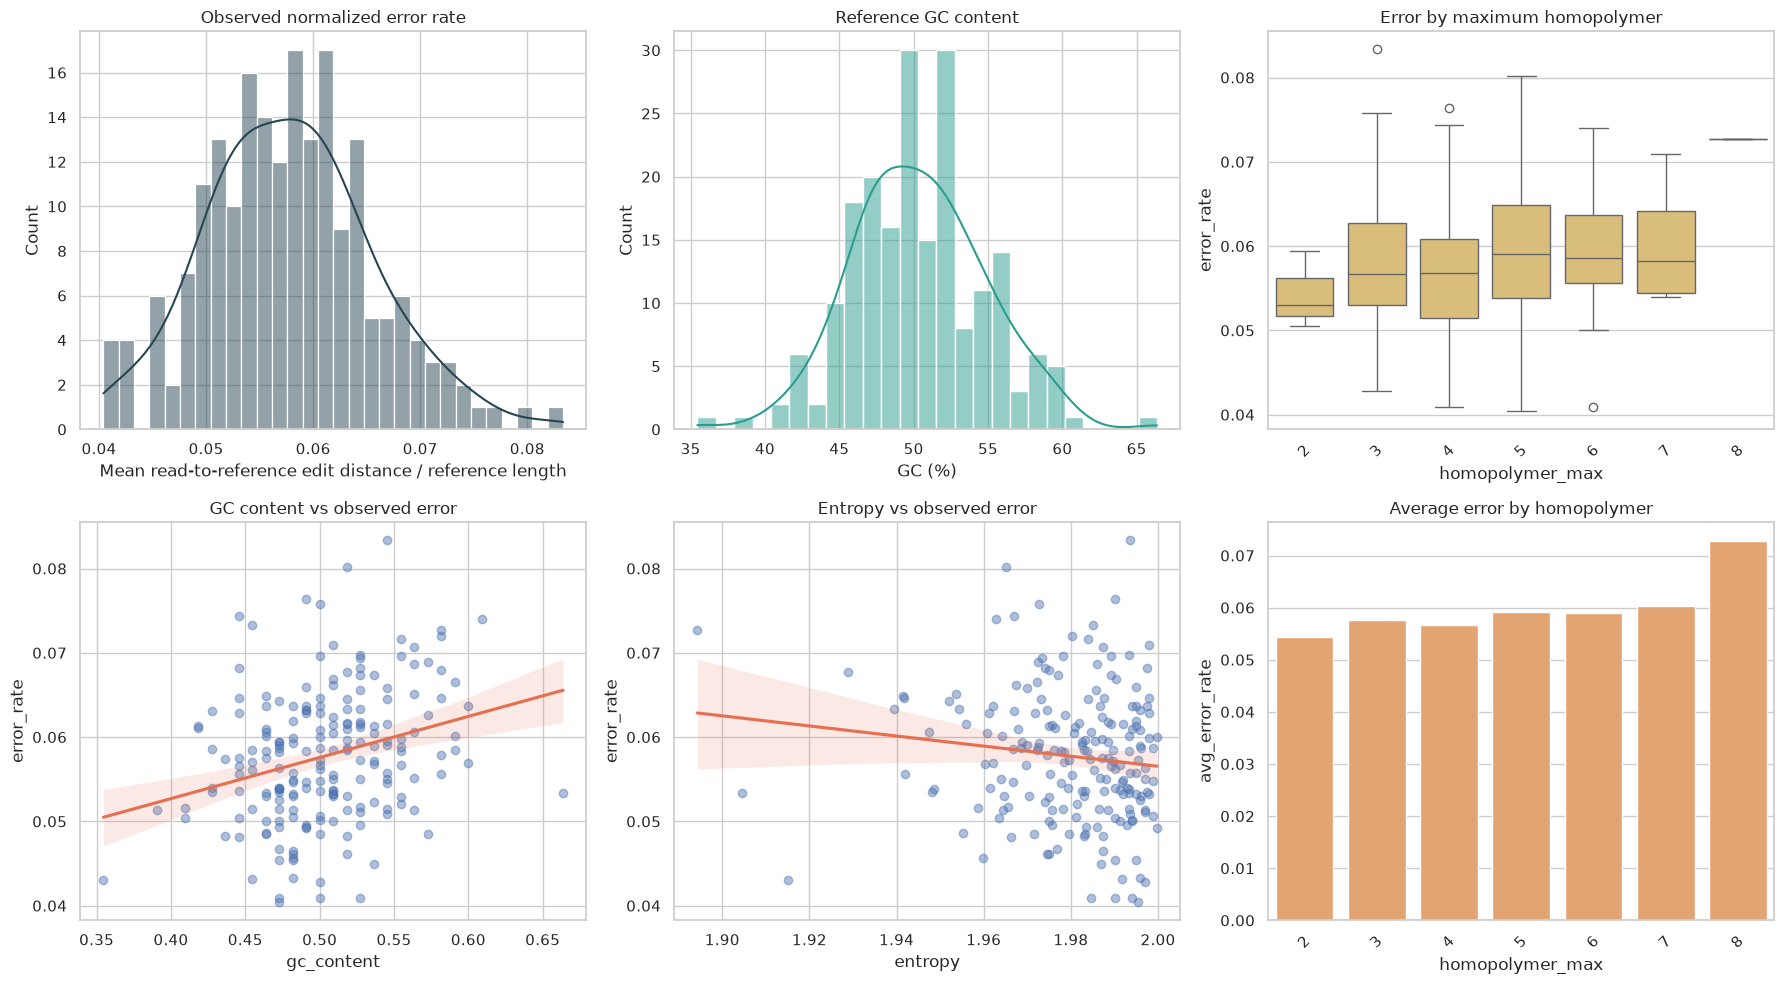

In [ ]:
eda_pd = clean_df.select('gc_content','gc_deviation','homopolymer_max','entropy','unique_kmer_ratio','repeat_ratio','length','error_rate','platform').toPandas()
sns.set_theme(style='whitegrid', context='notebook')
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.histplot(eda_pd['error_rate'], bins=30, kde=True, ax=axes[0,0], color='#264653')
axes[0,0].set_title('Observed normalized error rate')
axes[0,0].set_xlabel('Mean read-to-reference edit distance / reference length')

sns.histplot(eda_pd['gc_content'] * 100, bins=25, kde=True, ax=axes[0,1], color='#2a9d8f')
axes[0,1].set_title('Reference GC content')
axes[0,1].set_xlabel('GC (%)')

sns.boxplot(data=eda_pd, x='homopolymer_max', y='error_rate', ax=axes[0,2], color='#e9c46a')
axes[0,2].set_title('Error by maximum homopolymer')
axes[0,2].tick_params(axis='x', rotation=45)

sns.regplot(data=eda_pd, x='gc_content', y='error_rate', ax=axes[1,0], scatter_kws={'alpha':0.45}, line_kws={'color':'#e76f51'})
axes[1,0].set_title('GC content vs observed error')

sns.regplot(data=eda_pd, x='entropy', y='error_rate', ax=axes[1,1], scatter_kws={'alpha':0.45}, line_kws={'color':'#e76f51'})
axes[1,1].set_title('Entropy vs observed error')

sns.barplot(data=group_pd, x='homopolymer_max', y='avg_error_rate', ax=axes[1,2], color='#f4a261')
axes[1,2].set_title('Average error by homopolymer')
axes[1,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
eda_path = PROJECT_ROOT/'outputs/figures/eda_overview.png'
plt.savefig(eda_path, dpi=160, bbox_inches='tight')
plt.show()

## 09. Statistical analysis

Pearson correlation tests linear association; Spearman correlation tests monotonic association and is less sensitive to non-normality. Mutual information is estimated from a sampled local table and is treated as an exploratory dependence score rather than a significance test. The Kruskal–Wallis test compares observed-error distributions across homopolymer groups when at least two groups have observations.

In [ ]:
from sklearn.feature_selection import mutual_info_regression

numeric_cols = ['gc_content','gc_deviation','homopolymer_max','entropy','unique_kmer_ratio','repeat_ratio','length']
stat_rows = []
for col in numeric_cols:
    x = eda_pd[col].astype(float).values
    y = eda_pd['error_rate'].astype(float).values
    if np.std(x) == 0 or len(x) < 3:
        pearson_r = pearson_p = spearman_r = spearman_p = np.nan
    else:
        pearson_r, pearson_p = stats.pearsonr(x, y)
        spearman_r, spearman_p = stats.spearmanr(x, y)
    stat_rows.append({'feature': col, 'pearson_r': pearson_r, 'pearson_p': pearson_p,
                      'spearman_r': spearman_r, 'spearman_p': spearman_p})

stats_df = pd.DataFrame(stat_rows)
mi_input = eda_pd[numeric_cols].copy().fillna(eda_pd[numeric_cols].median())
mi_values = mutual_info_regression(mi_input, eda_pd['error_rate'], random_state=SEED)
stats_df['mutual_information'] = mi_values
stats_df.to_csv(PROJECT_ROOT/'outputs/tables/statistical_associations.csv', index=False)
display(stats_df.sort_values('mutual_information', ascending=False))

# Hypothesis test: maximum homopolymer and observed error.
groups = [g['error_rate'].values for _, g in eda_pd.groupby('homopolymer_max') if len(g) >= 2]
if len(groups) >= 2:
    kw_stat, kw_p = stats.kruskal(*groups)
    print(f'Kruskal-Wallis across homopolymer groups: statistic={kw_stat:.4f}, p={kw_p:.4g}')
else:
    kw_stat, kw_p = np.nan, np.nan
    print('Not enough non-trivial homopolymer groups for Kruskal-Wallis.')

,feature,pearson_r,pearson_p,spearman_r,spearman_p,mutual_information
0,gc_content,0.282912,0.000049,0.279492,0.000061,0.053957
1,gc_deviation,0.053969,0.447850,0.069158,0.330514,0.000000
2,homopolymer_max,0.127054,0.073002,0.123513,0.081427,0.000000
3,entropy,-0.128950,0.068789,-0.133637,0.059223,0.000000
4,unique_kmer_ratio,0.046435,0.513807,0.006593,0.926173,0.000000
5,repeat_ratio,-0.084590,0.233683,-0.084386,0.234820,0.000000
6,length,NaN,NaN,NaN,NaN,0.000000


Kruskal-Wallis across homopolymer groups: statistic=5.7052, p=0.336


## 10. Spark MLlib regression

The regression target is the observed error rate. Linear regression is the baseline and Random Forest regression is the nonlinear comparison. The selected features are sequence characteristics only; `error_rate` is never included as a predictor.

In [ ]:
FEATURE_COLS = ['gc_content','gc_deviation','homopolymer_max','entropy','unique_kmer_ratio','repeat_ratio','length']
assembler = VectorAssembler(inputCols=FEATURE_COLS, outputCol='features', handleInvalid='skip')
model_df = clean_df.select('sequence_id','sequence','platform','error_rate',*FEATURE_COLS).withColumn('label', F.col('error_rate'))
train_df, test_df = model_df.randomSplit([0.8, 0.2], seed=SEED)
print('Train rows:', train_df.count(), 'Test rows:', test_df.count())

regression_models = {
    'LinearRegression': LinearRegression(featuresCol='features', labelCol='label', predictionCol='prediction', maxIter=100, regParam=0.0),
    'RandomForestRegression': RandomForestRegressor(featuresCol='features', labelCol='label', predictionCol='prediction', numTrees=80, maxDepth=8, seed=SEED)
}
regression_results = []
regression_predictions = {}
for name, estimator in regression_models.items():
    pipeline = Pipeline(stages=[assembler, estimator])
    fitted = pipeline.fit(train_df)
    pred = fitted.transform(test_df).select('sequence_id','label','prediction')
    regression_predictions[name] = pred
    evaluator_rmse = RegressionEvaluator(labelCol='label', predictionCol='prediction', metricName='rmse')
    evaluator_mae = RegressionEvaluator(labelCol='label', predictionCol='prediction', metricName='mae')
    evaluator_r2 = RegressionEvaluator(labelCol='label', predictionCol='prediction', metricName='r2')
    regression_results.append({'model': name,
        'RMSE': evaluator_rmse.evaluate(pred), 'MAE': evaluator_mae.evaluate(pred), 'R2': evaluator_r2.evaluate(pred)})
    fitted.write().overwrite().save(str(PROJECT_ROOT/'models'/name))

regression_results_df = pd.DataFrame(regression_results).sort_values('RMSE')
regression_results_df.to_csv(PROJECT_ROOT/'outputs/tables/regression_results.csv', index=False)
display(regression_results_df)

Train rows: 154 Test rows: 46


26/08/24 07:28:55 WARN Instrumentation: [a3f492d6] regParam is zero, which might cause numerical instability and overfitting.
26/08/24 07:28:55 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS


26/08/24 07:28:55 WARN Instrumentation: [a3f492d6] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.


,model,RMSE,MAE,R2
0,LinearRegression,0.007871,0.006088,0.140288
1,RandomForestRegression,0.008600,0.006824,-0.026167


## 11. Spark MLlib classification

Risk classes are defined from the empirical error-rate tertiles of the selected observed data. This is a reproducible, data-derived operational grouping, not a universal biological threshold. Accuracy is reported together with weighted precision, recall, and F1 because class balance can vary.

In [ ]:
q33, q67 = clean_df.approxQuantile('error_rate', [0.333333, 0.666667], 0.0)
print('Empirical class thresholds:', q33, q67)
class_df = (model_df
    .withColumn('risk_label', F.when(F.col('error_rate') <= F.lit(q33), F.lit(0.0))
                .when(F.col('error_rate') <= F.lit(q67), F.lit(1.0)).otherwise(F.lit(2.0))))
class_train, class_test = class_df.randomSplit([0.8, 0.2], seed=SEED)

classification_estimators = {
    'LogisticRegression': LogisticRegression(featuresCol='features', labelCol='risk_label', predictionCol='prediction',
                                             probabilityCol='probability', rawPredictionCol='rawPrediction',
                                             maxIter=100, family='multinomial'),
    'DecisionTreeClassifier': DecisionTreeClassifier(featuresCol='features', labelCol='risk_label', predictionCol='prediction',
                                                     maxDepth=6, seed=SEED),
    'RandomForestClassifier': RandomForestClassifier(featuresCol='features', labelCol='risk_label', predictionCol='prediction',
                                                     numTrees=80, maxDepth=8, seed=SEED)
}
classification_results = []
classification_predictions = {}
for name, estimator in classification_estimators.items():
    pipe = Pipeline(stages=[assembler, estimator])
    fitted = pipe.fit(class_train)
    pred = fitted.transform(class_test).select('sequence_id','risk_label','prediction','probability')
    classification_predictions[name] = pred
    metrics = {}
    for metric in ['accuracy','weightedPrecision','weightedRecall','f1']:
        ev = MulticlassClassificationEvaluator(labelCol='risk_label', predictionCol='prediction', metricName=metric)
        metrics[metric] = ev.evaluate(pred)
    classification_results.append({'model': name, **metrics})
    fitted.write().overwrite().save(str(PROJECT_ROOT/'models'/name))

classification_results_df = pd.DataFrame(classification_results).sort_values('f1', ascending=False)
classification_results_df.to_csv(PROJECT_ROOT/'outputs/tables/classification_results.csv', index=False)
display(classification_results_df)

best_classifier_name = classification_results_df.iloc[0]['model']
confusion_pd = classification_predictions[best_classifier_name].groupBy('risk_label','prediction').count().toPandas()
confusion_matrix = confusion_pd.pivot(index='risk_label', columns='prediction', values='count').fillna(0)
print('Confusion matrix for:', best_classifier_name)
display(confusion_matrix)
confusion_matrix.to_csv(PROJECT_ROOT/'outputs/tables/confusion_matrix.csv')

Empirical class thresholds: 0.05381818181818181 0.06083916083916084


,model,accuracy,weightedPrecision,weightedRecall,f1
0,LogisticRegression,0.478261,0.500801,0.478261,0.479375
2,RandomForestClassifier,0.369565,0.377536,0.369565,0.371542
1,DecisionTreeClassifier,0.369565,0.411331,0.369565,0.366683


Confusion matrix for: LogisticRegression


prediction,0.0,1.0,2.0
risk_label,,,
0.0,9.0,4.0,0.0
1.0,4.0,6.0,5.0
2.0,2.0,9.0,7.0


## 12. K-means clustering

Clustering uses sequence features without the observed-error target. The silhouette score is used to compare candidate values of `k`; cluster-level mean error is shown only after fitting so that reliability differences can be interpreted post hoc.

In [ ]:
cluster_assembler = VectorAssembler(inputCols=FEATURE_COLS, outputCol='raw_features', handleInvalid='skip')
scaler = StandardScaler(inputCol='raw_features', outputCol='scaled_features', withStd=True, withMean=True)
cluster_base = clean_df.select('sequence_id','error_rate',*FEATURE_COLS)
cluster_eval_rows = []
cluster_models = {}
for k in [2,3,4]:
    km = KMeans(featuresCol='scaled_features', predictionCol='cluster', k=k, seed=SEED, maxIter=50)
    pipe = Pipeline(stages=[cluster_assembler, scaler, km])
    fitted = pipe.fit(cluster_base)
    pred = fitted.transform(cluster_base)
    silhouette = pred.select(F.expr('silhouette(vector_to_array(scaled_features), cluster)').alias('s')).first() if False else None
    # Spark's evaluator is used directly because it handles the feature vector column.
    from pyspark.ml.evaluation import ClusteringEvaluator
    evaluator = ClusteringEvaluator(featuresCol='scaled_features', predictionCol='cluster', metricName='silhouette', distanceMeasure='squaredEuclidean')
    score = evaluator.evaluate(pred)
    cluster_eval_rows.append({'k': k, 'silhouette': score})
    cluster_models[k] = (fitted, pred)

cluster_eval_df = pd.DataFrame(cluster_eval_rows)
best_k = int(cluster_eval_df.sort_values('silhouette', ascending=False).iloc[0]['k'])
best_cluster_pred = cluster_models[best_k][1]
cluster_summary = (best_cluster_pred.groupBy('cluster').agg(
    F.count('*').alias('n'), F.avg('error_rate').alias('avg_error_rate'), F.avg('gc_content').alias('avg_gc'),
    F.avg('homopolymer_max').alias('avg_homopolymer'), F.avg('entropy').alias('avg_entropy'))
    .orderBy('cluster'))
cluster_summary_pd = cluster_summary.toPandas()
cluster_eval_df.to_csv(PROJECT_ROOT/'outputs/tables/clustering_results.csv', index=False)
cluster_summary_pd.to_csv(PROJECT_ROOT/'outputs/tables/cluster_summary.csv', index=False)
print('Best k:', best_k)
display(cluster_eval_df)
display(cluster_summary_pd)

Best k: 3


,k,silhouette
0,2,0.335427
1,3,0.344763
2,4,0.317511


,cluster,n,avg_error_rate,avg_gc,avg_homopolymer,avg_entropy
0,0,98,0.056132,0.494156,4.265306,1.988561
1,1,68,0.057964,0.482888,3.764706,1.974227
2,2,34,0.061954,0.570856,4.117647,1.965773


## 13. Feature importance and permutation importance

Random Forest importance is measured with Spark MLlib. Permutation importance is measured on a bounded Pandas sample using a scikit-learn Random Forest, which provides a model-agnostic check. If the analytical sample is small, these should be interpreted as exploratory rather than stable population estimates.

In [ ]:
# Spark RF feature importance from the fitted regression pipeline.
rf_pipe = Pipeline(stages=[assembler, regression_models['RandomForestRegression']]).fit(train_df)
rf_stage = rf_pipe.stages[-1]
rf_importance = dict(zip(FEATURE_COLS, rf_stage.featureImportances.toArray()))

from sklearn.ensemble import RandomForestRegressor as SKRandomForestRegressor
from sklearn.inspection import permutation_importance
X = feature_pd[FEATURE_COLS].astype(float).fillna(feature_pd[FEATURE_COLS].median())
y = feature_pd['error_rate'].astype(float)
sk_rf = SKRandomForestRegressor(n_estimators=200, random_state=SEED, min_samples_leaf=2, n_jobs=-1)
sk_rf.fit(X, y)
perm = permutation_importance(sk_rf, X, y, n_repeats=10, random_state=SEED, scoring='neg_mean_absolute_error')
importance_pd = pd.DataFrame({
    'feature': FEATURE_COLS,
    'spark_rf_importance': [rf_importance.get(f, 0.0) for f in FEATURE_COLS],
    'permutation_mean': perm.importances_mean,
    'permutation_std': perm.importances_std,
}).sort_values('spark_rf_importance', ascending=False)
importance_pd.to_csv(PROJECT_ROOT/'outputs/tables/feature_importance.csv', index=False)
display(importance_pd)

,feature,spark_rf_importance,permutation_mean,permutation_std
3,entropy,0.223821,1.736767e-03,8.791129e-05
0,gc_content,0.195871,1.899843e-03,1.598317e-04
4,unique_kmer_ratio,0.173833,1.072408e-03,8.062825e-05
5,repeat_ratio,0.152879,1.077501e-03,6.381753e-05
1,gc_deviation,0.134639,5.528943e-04,2.955644e-05
2,homopolymer_max,0.118958,8.508530e-04,6.878476e-05
6,length,0.000000,-3.903128e-19,5.962126e-19


## 14. Similarity graph and GraphX-compatible design

A full all-vs-all sequence graph is quadratic. The executable Python graph therefore uses a bounded sample and a k-nearest strategy. Vertices are reference sequences, edges represent high normalized similarity, and edge weights are similarity scores. The graph computes degree, connected components, and PageRank, then compares graph communities with error rate.

For strict Scala GraphX submission requirements, the following conceptual translation is included after the executable section. GraphX is a Scala Spark API; a standard Python Colab runtime does not expose it as a native Python library.

In [ ]:
GRAPH_N = min(250, clean_df.count())
graph_pd = clean_df.select('sequence_id','sequence','error_rate').orderBy('sequence_id').limit(GRAPH_N).toPandas()

def similarity(a, b):
    # Similarity for equal-length reference strings; otherwise use edit distance.
    denom = max(len(a), len(b), 1)
    return 1.0 - levenshtein(a, b) / denom

G = nx.Graph()
for row in graph_pd.itertuples(index=False):
    G.add_node(row.sequence_id, error_rate=float(row.error_rate), sequence=row.sequence)

top_k = 5
threshold = 0.82
for i, r1 in graph_pd.iterrows():
    candidates = []
    for j, r2 in graph_pd.iterrows():
        if i == j:
            continue
        sim = similarity(r1.sequence, r2.sequence)
        candidates.append((sim, r2.sequence_id))
    for sim, other_id in sorted(candidates, reverse=True)[:top_k]:
        if sim >= threshold:
            G.add_edge(r1.sequence_id, other_id, weight=float(sim))

degree = dict(G.degree())
components = {node: cid for cid, comp in enumerate(nx.connected_components(G)) for node in comp}
pagerank = nx.pagerank(G, weight='weight') if G.number_of_edges() else {n: 1/G.number_of_nodes() for n in G.nodes()}
graph_metrics_pd = pd.DataFrame([{'sequence_id': n, 'degree': degree[n], 'component': components[n], 'pagerank': pagerank[n],
                                  'error_rate': G.nodes[n]['error_rate']} for n in G.nodes()])
component_summary_pd = graph_metrics_pd.groupby('component').agg(n=('sequence_id','size'), avg_error_rate=('error_rate','mean'),
                                                                  avg_degree=('degree','mean')).reset_index()
graph_metrics_pd.to_csv(PROJECT_ROOT/'outputs/tables/graph_metrics.csv', index=False)
component_summary_pd.to_csv(PROJECT_ROOT/'outputs/tables/graph_component_summary.csv', index=False)
print('Graph nodes:', G.number_of_nodes(), 'edges:', G.number_of_edges(), 'components:', nx.number_connected_components(G))
display(component_summary_pd.sort_values('avg_error_rate', ascending=False).head(10))

Graph nodes: 200 edges: 0 components: 200


,component,n,avg_error_rate,avg_degree
164,164,1,0.083333,0.0
112,112,1,0.080165,0.0
160,160,1,0.076364,0.0
78,78,1,0.075758,0.0
62,62,1,0.074380,0.0
31,31,1,0.074000,0.0
181,181,1,0.073295,0.0
29,29,1,0.072727,0.0
188,188,1,0.072028,0.0
5,5,1,0.071591,0.0


### GraphX translation for a Scala/Spark cell

```scala
// GraphX sketch: execute in a Scala-enabled Spark notebook/runtime if strict GraphX evidence is required.
import org.apache.spark.graphx._
import org.apache.spark.rdd.RDD

case class VertexAttr(sequenceId: String, errorRate: Double)
case class EdgeAttr(similarity: Double)

val vertices: RDD[(VertexId, VertexAttr)] = ...
val edges: RDD[Edge[EdgeAttr]] = ...
val graph = Graph(vertices, edges)
val degrees = graph.degrees
val components = graph.connectedComponents().vertices
val ranks = graph.pageRank(0.0001).vertices
```

The Python execution above uses the same vertex/edge semantics and computes the requested metrics without pretending that PySpark is GraphX.

## 15. DSQI construction

The DSQI is defined as a weighted quality score on a 0–100 scale. Its components are normalized to `[0, 1]`:

| Component | Interpretation |
|---|---|
| GC suitability | Closeness to the empirical reference GC target |
| Homopolymer safety | Lower risk for long maximum runs |
| Entropy quality | Higher sequence entropy |
| k-mer complexity | Higher unique 3-mer ratio |
| Length suitability | Closeness to the central observed length range |

Three weighting strategies are compared: equal weights, weights based on absolute Spearman association with observed error, and weights based on Random Forest importance. These are **dataset-specific empirical scores**, not universal physical laws.

In [ ]:
# Robust helpers for DSQI normalization.
def minmax_clip(series, lo=None, hi=None, invert=False):
    s = pd.Series(series, dtype=float)
    lo = float(s.quantile(0.05) if lo is None else lo)
    hi = float(s.quantile(0.95) if hi is None else hi)
    if hi <= lo:
        out = pd.Series(np.ones(len(s)), index=s.index)
    else:
        out = ((s - lo) / (hi - lo)).clip(0, 1)
    return 1 - out if invert else out

score_pd = feature_pd.copy()
median_length = float(score_pd['length'].median())
q10_length, q90_length = score_pd['length'].quantile([0.10, 0.90])
length_span = max(float(q90_length - q10_length), 1.0)

score_pd['gc_suitability'] = (1 - score_pd['gc_deviation'] / max(score_pd['gc_deviation'].quantile(0.95), 1e-9)).clip(0, 1)
score_pd['homopolymer_safety'] = minmax_clip(score_pd['homopolymer_max'], invert=True)
score_pd['entropy_quality'] = (score_pd['entropy'] / math.log2(4)).clip(0, 1)
score_pd['kmer_complexity'] = score_pd['unique_kmer_ratio'].clip(0, 1)
score_pd['length_suitability'] = (1 - (score_pd['length'] - median_length).abs() / length_span).clip(0, 1)

QUALITY_COMPONENTS = ['gc_suitability','homopolymer_safety','entropy_quality','kmer_complexity','length_suitability']
BASE_FOR_IMPORTANCE = ['gc_deviation','homopolymer_max','entropy','unique_kmer_ratio','length']

# Equal weights.
equal_weights = {c: 1/len(QUALITY_COMPONENTS) for c in QUALITY_COMPONENTS}

# Statistical weights: absolute Spearman association with error; equal fallback for constant features.
stat_weights_raw = {}
for q, base in zip(QUALITY_COMPONENTS, BASE_FOR_IMPORTANCE):
    if score_pd[q].nunique() <= 1:
        stat_weights_raw[q] = 0.0
    else:
        stat_weights_raw[q] = abs(stats.spearmanr(score_pd[q], score_pd['error_rate']).statistic)
if sum(stat_weights_raw.values()) == 0:
    stat_weights = equal_weights.copy()
else:
    stat_weights = {k: v/sum(stat_weights_raw.values()) for k,v in stat_weights_raw.items()}

# Model-derived weights map Spark RF importance onto the score components.
model_raw = {q: float(rf_importance.get(base, 0.0)) for q, base in zip(QUALITY_COMPONENTS, BASE_FOR_IMPORTANCE)}
if sum(model_raw.values()) == 0:
    model_weights = equal_weights.copy()
else:
    model_weights = {k: v/sum(model_raw.values()) for k,v in model_raw.items()}

weights_table = pd.DataFrame([
    {'strategy': 'equal', 'component': k, 'weight': v} for k,v in equal_weights.items()
] + [
    {'strategy': 'statistical', 'component': k, 'weight': v} for k,v in stat_weights.items()
] + [
    {'strategy': 'model_derived', 'component': k, 'weight': v} for k,v in model_weights.items()
])
weights_table.to_csv(PROJECT_ROOT/'outputs/tables/dsqi_weights.csv', index=False)

def weighted_score(row, weights):
    return 100 * sum(float(row[c]) * weights[c] for c in QUALITY_COMPONENTS)

for strategy, weights in [('equal', equal_weights), ('statistical', stat_weights), ('model_derived', model_weights)]:
    score_pd[f'dsqi_{strategy}'] = score_pd.apply(lambda r: weighted_score(r, weights), axis=1)

print('DSQI weights:')
display(weights_table.pivot(index='component', columns='strategy', values='weight'))

DSQI weights:


strategy,equal,model_derived,statistical
component,,,
entropy_quality,0.2,0.343678,0.405914
gc_suitability,0.2,0.206739,0.213759
homopolymer_safety,0.2,0.182660,0.360300
kmer_complexity,0.2,0.266923,0.020027
length_suitability,0.2,0.000000,0.000000


## 16. DSQI validation and explainability

Validation asks whether higher DSQI corresponds to lower observed error in held-out rows and in the full selected benchmark. Because a score can be monotonic without being calibrated as a probability, the primary checks are Spearman association, quantile-group error summaries, and a simple monotonicity check across low/medium/high DSQI groups.

In [ ]:
validation_rows = []
for strategy in ['equal','statistical','model_derived']:
    col = f'dsqi_{strategy}'
    score_pd[f'{col}_band'] = pd.qcut(score_pd[col], q=3, labels=['Low DSQI','Medium DSQI','High DSQI'], duplicates='drop')
    band_summary = score_pd.groupby(f'{col}_band', observed=False).agg(n=('sequence_id','size'), mean_error=('error_rate','mean'),
                                                                         median_error=('error_rate','median'), mean_dsqi=(col,'mean')).reset_index()
    band_summary['strategy'] = strategy
    band_summary.rename(columns={f'{col}_band':'dsqi_band'}, inplace=True)
    validation_rows.append(band_summary)
    rho, p = stats.spearmanr(score_pd[col], score_pd['error_rate']) if score_pd[col].nunique() > 1 else (np.nan, np.nan)
    print(f'{strategy}: Spearman(DSQI, error)={rho:.4f}, p={p:.4g}')

validation_pd = pd.concat(validation_rows, ignore_index=True)
validation_pd.to_csv(PROJECT_ROOT/'outputs/tables/dsqi_validation.csv', index=False)
display(validation_pd)

# Explain the lowest-scoring sequence using the model-derived score.
explain_row = score_pd.sort_values('dsqi_model_derived').iloc[0]
contributions = pd.DataFrame({'component': QUALITY_COMPONENTS,
                              'component_score': [explain_row[c] for c in QUALITY_COMPONENTS],
                              'weight': [model_weights[c] for c in QUALITY_COMPONENTS]})
contributions['weighted_points'] = 100 * contributions['component_score'] * contributions['weight']
print('Lowest model-derived DSQI sequence:', explain_row['sequence_id'])
print('DSQI:', round(explain_row['dsqi_model_derived'], 2), 'Observed error:', round(explain_row['error_rate'], 4))
display(contributions.sort_values('weighted_points'))
contributions.to_csv(PROJECT_ROOT/'outputs/tables/lowest_dsqi_explanation.csv', index=False)

equal: Spearman(DSQI, error)=-0.1327, p=0.06099
statistical: Spearman(DSQI, error)=-0.1408, p=0.04676
model_derived: Spearman(DSQI, error)=-0.1310, p=0.06453


,dsqi_band,n,mean_error,median_error,mean_dsqi,strategy
0,Low DSQI,67,0.058744,0.058545,64.638915,equal
1,Medium DSQI,66,0.057276,0.057435,75.440767,equal
2,High DSQI,67,0.057207,0.056250,83.565910,equal
3,Low DSQI,67,0.059744,0.060140,62.716681,statistical
4,Medium DSQI,66,0.056459,0.055435,78.558914,statistical
5,High DSQI,67,0.057011,0.056250,90.988157,statistical
6,Low DSQI,67,0.059278,0.058824,61.546814,model_derived
7,Medium DSQI,66,0.056666,0.057056,72.274111,model_derived
8,High DSQI,67,0.057273,0.056250,80.086617,model_derived


Lowest model-derived DSQI sequence: CNR_00029
DSQI: 46.07 Observed error: 0.0727


,component,component_score,weight,weighted_points
1,homopolymer_safety,0.000000,0.182660,0.000000
4,length_suitability,1.000000,0.000000,0.000000
0,gc_suitability,0.103842,0.206739,2.146824
3,kmer_complexity,0.425926,0.266923,11.368924
2,entropy_quality,0.947141,0.343678,32.551139


## 17. Cross-dataset and cross-platform validation hook

The public DNAformer sample does not include a released reference/read error table in the repository, so it cannot be used for an honest numeric external validation by default. The next function accepts a user-provided labeled CSV with columns `sequence_id`, `sequence`, `error_rate`, and optional `platform`. It applies the already learned feature definitions and weights without retraining. If the file is absent, the notebook records the validation as pending rather than fabricating a result.

In [ ]:
EXTERNAL_CSV = PROJECT_ROOT/'data/external/external_labeled_sequences.csv'

def featurize_external_csv(path):
    ext = pd.read_csv(path)
    required = {'sequence_id','sequence','error_rate'}
    missing = required - set(ext.columns)
    if missing:
        raise ValueError(f'External CSV is missing required columns: {sorted(missing)}')
    if 'platform' not in ext.columns:
        ext['platform'] = 'external_unknown'
    ext['sequence'] = ext['sequence'].astype(str).str.upper()
    ext = ext[ext['sequence'].map(lambda s: bool(s) and set(s) <= set('ACGT'))].copy()
    ext['length'] = ext['sequence'].str.len()
    ext['gc_content'] = ext['sequence'].map(lambda s: (s.count('G')+s.count('C'))/max(len(s),1))
    ext['gc_deviation'] = (ext['gc_content'] - reference_gc).abs()
    ext['homopolymer_max'] = ext['sequence'].map(max_homopolymer)
    ext['entropy'] = ext['sequence'].map(shannon_entropy)
    ext['unique_kmer_ratio'] = ext['sequence'].map(lambda s: kmer_unique_ratio(s, 3))
    ext['repeat_ratio'] = ext['sequence'].map(lambda s: repeat_ratio(s, 3))
    ext['read_count'] = ext.get('read_count', 0)
    ext['gc_suitability'] = (1 - ext['gc_deviation'] / max(score_pd['gc_deviation'].quantile(0.95), 1e-9)).clip(0, 1)
    ext['homopolymer_safety'] = 1 - ((ext['homopolymer_max'] - score_pd['homopolymer_max'].quantile(0.05)) /
                                     max(score_pd['homopolymer_max'].quantile(0.95)-score_pd['homopolymer_max'].quantile(0.05), 1e-9)).clip(0,1)
    ext['entropy_quality'] = (ext['entropy']/math.log2(4)).clip(0,1)
    ext['kmer_complexity'] = ext['unique_kmer_ratio'].clip(0,1)
    ext['length_suitability'] = (1 - (ext['length']-median_length).abs()/length_span).clip(0,1)
    ext['dsqi_model_derived'] = ext.apply(lambda r: weighted_score(r, model_weights), axis=1)
    return ext

if Path(EXTERNAL_CSV).exists():
    external_pd = featurize_external_csv(EXTERNAL_CSV)
    rho_ext, p_ext = stats.spearmanr(external_pd['dsqi_model_derived'], external_pd['error_rate']) if external_pd['dsqi_model_derived'].nunique() > 1 else (np.nan, np.nan)
    external_result = pd.DataFrame([{'dataset': str(EXTERNAL_CSV), 'n': len(external_pd), 'spearman_dsqi_error': rho_ext, 'p_value': p_ext}])
    display(external_result)
    external_result.to_csv(PROJECT_ROOT/'outputs/tables/external_validation.csv', index=False)
else:
    print('External validation pending. Add a labeled CSV at:', EXTERNAL_CSV)
    print('Required columns: sequence_id, sequence, error_rate; optional: platform, read_count')

print('Cross-platform summary from currently available data:')
display(score_pd.groupby('platform').agg(n=('sequence_id','size'), mean_dsqi=('dsqi_model_derived','mean'), mean_error=('error_rate','mean')).reset_index())

External validation pending. Add a labeled CSV at: /home/ubuntu/DSQI_smoke/data/external/external_labeled_sequences.csv
Required columns: sequence_id, sequence, error_rate; optional: platform, read_count
Cross-platform summary from currently available data:


,platform,n,mean_dsqi,mean_error
0,Oxford Nanopore,200,71.297656,0.057745


## 18. Visualization dashboard

The dashboard combines the principal descriptive, model, feature-importance, and DSQI views. It is saved as a PNG for inclusion in a report or presentation.

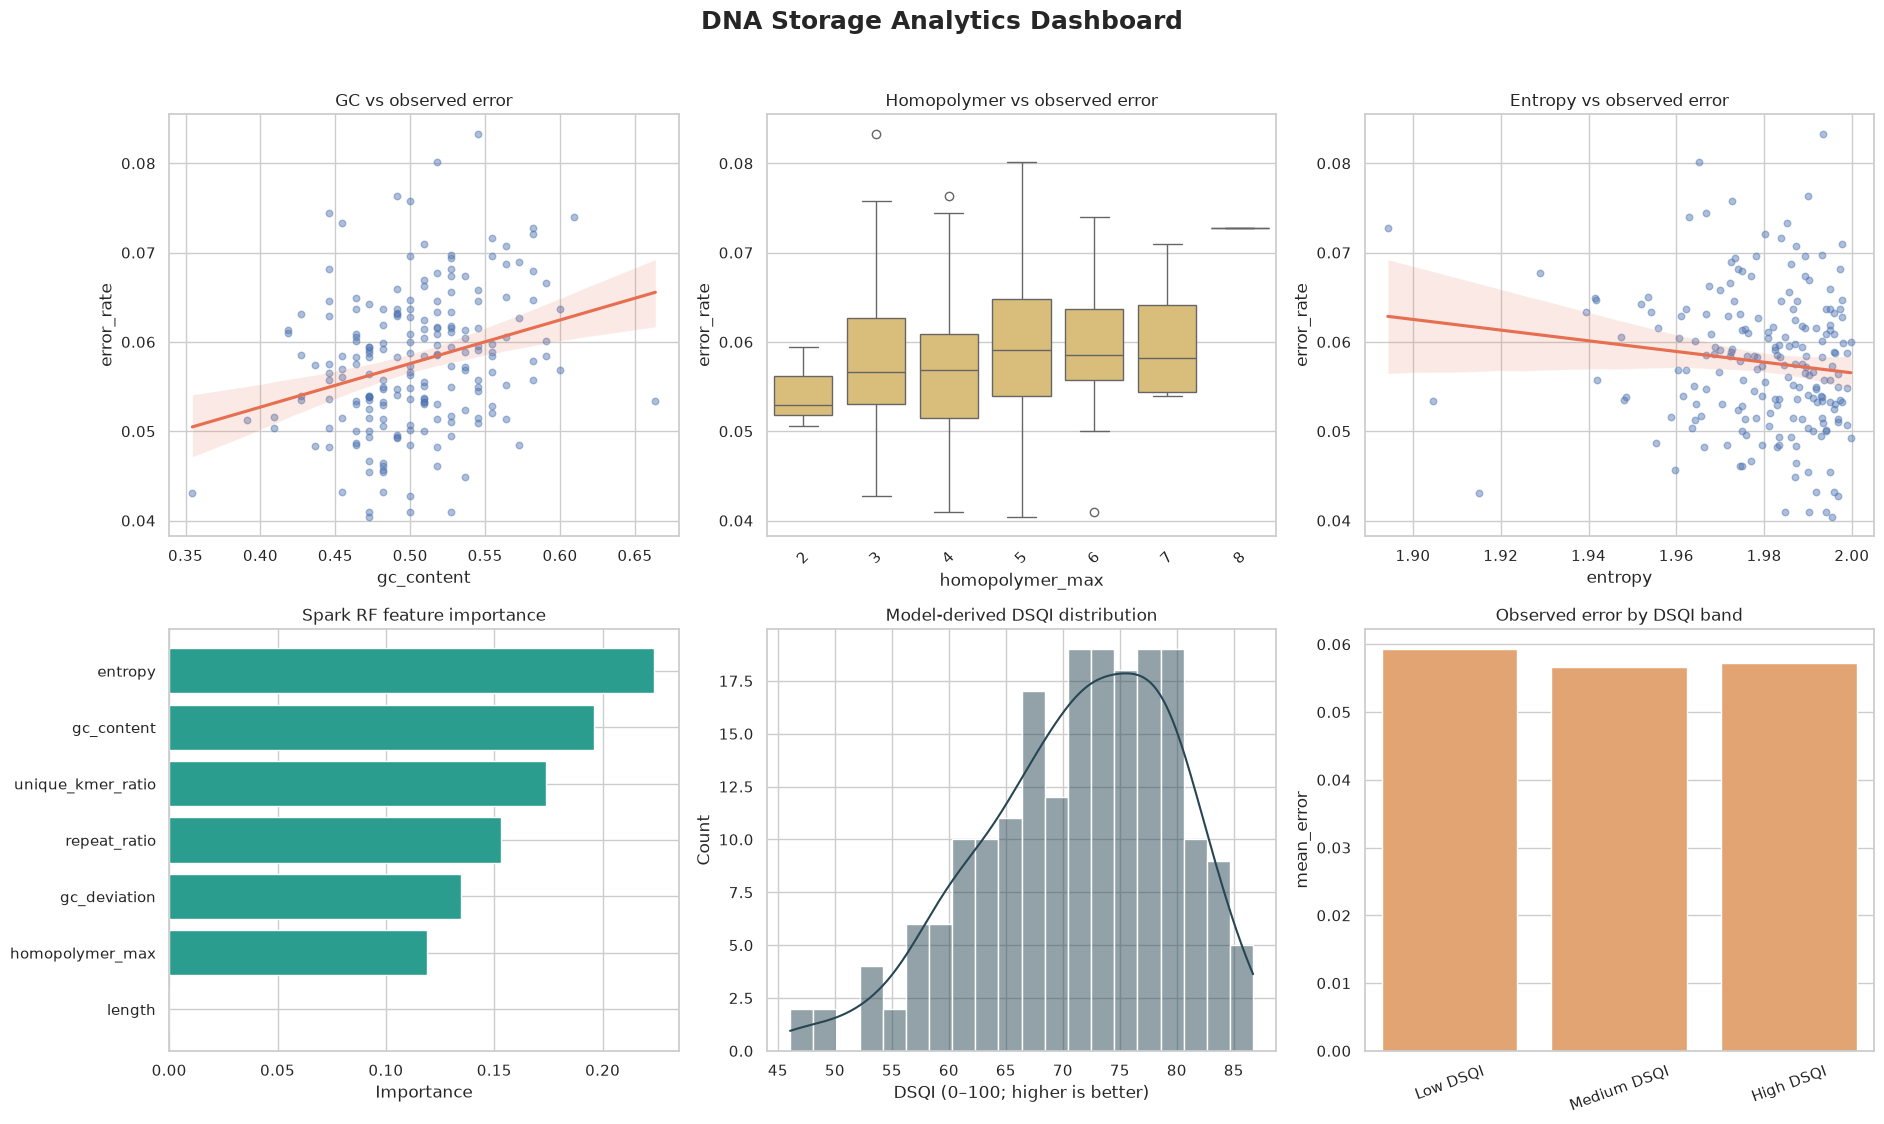

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(19, 11))
fig.suptitle('DNA Storage Analytics Dashboard', fontsize=18, fontweight='bold', y=1.02)

sns.regplot(data=score_pd, x='gc_content', y='error_rate', ax=axes[0,0], scatter_kws={'alpha':0.45, 's':22}, line_kws={'color':'#e76f51'})
axes[0,0].set_title('GC vs observed error')

sns.boxplot(data=score_pd, x='homopolymer_max', y='error_rate', ax=axes[0,1], color='#e9c46a')
axes[0,1].set_title('Homopolymer vs observed error')
axes[0,1].tick_params(axis='x', rotation=45)

sns.regplot(data=score_pd, x='entropy', y='error_rate', ax=axes[0,2], scatter_kws={'alpha':0.45, 's':22}, line_kws={'color':'#e76f51'})
axes[0,2].set_title('Entropy vs observed error')

importance_plot = importance_pd.sort_values('spark_rf_importance')
axes[1,0].barh(importance_plot['feature'], importance_plot['spark_rf_importance'], color='#2a9d8f')
axes[1,0].set_title('Spark RF feature importance')
axes[1,0].set_xlabel('Importance')

sns.histplot(score_pd['dsqi_model_derived'], bins=20, kde=True, ax=axes[1,1], color='#264653')
axes[1,1].set_title('Model-derived DSQI distribution')
axes[1,1].set_xlabel('DSQI (0–100; higher is better)')

band_plot = validation_pd[validation_pd['strategy']=='model_derived']
sns.barplot(data=band_plot, x='dsqi_band', y='mean_error', ax=axes[1,2], color='#f4a261', order=['Low DSQI','Medium DSQI','High DSQI'])
axes[1,2].set_title('Observed error by DSQI band')
axes[1,2].set_xlabel('')
axes[1,2].tick_params(axis='x', rotation=20)

plt.tight_layout()
dashboard_path = PROJECT_ROOT/'outputs/figures/dsqi_dashboard.png'
plt.savefig(dashboard_path, dpi=180, bbox_inches='tight')
plt.show()

## 19. Reproducibility manifest and final results

The next cell writes the experiment configuration and a compact result inventory. The generated files include the clean Parquet feature table, model metrics, cluster summaries, graph metrics, DSQI weights and validation, explanations, and figures.

In [ ]:
config = {
    'project': 'DNA Storage Quality Index',
    'dataset': 'Microsoft Clustered Nanopore Reads (CNR)',
    'dnaformer_sample_inspected': bool(DNAFORMER_FASTQ_PATH.exists()),
    'max_centers': MAX_CENTERS,
    'max_reads_per_center': MAX_READS_PER_CENTER,
    'graph_n': GRAPH_N,
    'random_seed': SEED,
    'reference_gc_target': reference_gc,
    'classification_thresholds': {'low_medium': float(q33), 'medium_high': float(q67)},
    'feature_columns': FEATURE_COLS,
    'quality_components': QUALITY_COMPONENTS,
    'spark_version': spark.version,
    'python_version': sys.version,
    'spark_master': sc.master,
    'limitations': [
        'Spark is running in Colab local mode, not a multi-node cluster.',
        'The default CNR subset is bounded for runtime and is not the complete release.',
        'Observed error is mean normalized edit distance from each noisy read to the released center.',
        'Graph analytics use a bounded k-nearest sample rather than full all-vs-all similarity.',
        'DNAformer full experimental datasets are not publicly included in its repository; external validation remains optional until labeled data are supplied.'
    ]
}
with open(PROJECT_ROOT/'outputs/experiment_config.json', 'w') as f:
    json.dump(config, f, indent=2, default=str)

results_inventory = []
for p in sorted((PROJECT_ROOT/'outputs').rglob('*')):
    if p.is_file():
        results_inventory.append({'path': str(p.relative_to(PROJECT_ROOT)), 'size_bytes': p.stat().st_size})
inventory_pd = pd.DataFrame(results_inventory)
inventory_pd.to_csv(PROJECT_ROOT/'outputs/tables/results_inventory.csv', index=False)
print('Results written under:', PROJECT_ROOT/'outputs')
display(inventory_pd)

Results written under: /home/ubuntu/DSQI_smoke/outputs


,path,size_bytes
0,outputs/experiment_config.json,1369
1,outputs/figures/dsqi_dashboard.png,399919
2,outputs/figures/eda_overview.png,359565
3,outputs/tables/classification_results.csv,346
4,outputs/tables/cluster_summary.csv,300
5,outputs/tables/clustering_results.csv,77
6,outputs/tables/confusion_matrix.csv,71
7,outputs/tables/dataset_manifest.csv,718
8,outputs/tables/dsqi_validation.csv,798
9,outputs/tables/dsqi_weights.csv,625


## 20. Research conclusions template

Run the following cell only after reviewing the numeric tables and plots. It prints evidence-linked statements without hard-coding a preferred conclusion. A scientifically valid submission should replace the template language with the actual observed values and should report contradictions to the initial hypotheses.

In [ ]:
print('FINAL EVIDENCE SUMMARY')
print('======================')
print(f'Analytical sequences: {len(score_pd)}')
print(f'Mean observed error rate: {score_pd.error_rate.mean():.6f}')
print(f'Median observed error rate: {score_pd.error_rate.median():.6f}')
print(f'Best regression model by RMSE: {regression_results_df.iloc[0].model} (RMSE={regression_results_df.iloc[0].RMSE:.6f}, R2={regression_results_df.iloc[0].R2:.4f})')
print(f'Best classification model by weighted F1: {classification_results_df.iloc[0].model} (F1={classification_results_df.iloc[0].f1:.4f})')
print(f'Best clustering k by silhouette: {best_k} (score={cluster_eval_df.sort_values("silhouette", ascending=False).iloc[0].silhouette:.4f})')
for strategy in ['equal','statistical','model_derived']:
    rho, p = stats.spearmanr(score_pd[f'dsqi_{strategy}'], score_pd['error_rate']) if score_pd[f'dsqi_{strategy}'].nunique() > 1 else (np.nan, np.nan)
    print(f'{strategy} DSQI Spearman association with error: rho={rho:.4f}, p={p:.4g}')
print('\nInterpretation rule: a negative DSQI–error association supports the intended ordering; a weak, null, or positive association should be reported as evidence against that intended ordering for this subset.')

FINAL EVIDENCE SUMMARY
Analytical sequences: 200
Mean observed error rate: 0.057745
Median observed error rate: 0.057576
Best regression model by RMSE: LinearRegression (RMSE=0.007871, R2=0.1403)
Best classification model by weighted F1: LogisticRegression (F1=0.4794)
Best clustering k by silhouette: 3 (score=0.3448)
equal DSQI Spearman association with error: rho=-0.1327, p=0.06099
statistical DSQI Spearman association with error: rho=-0.1408, p=0.04676
model_derived DSQI Spearman association with error: rho=-0.1310, p=0.06453

Interpretation rule: a negative DSQI–error association supports the intended ordering; a weak, null, or positive association should be reported as evidence against that intended ordering for this subset.


## References

[1] Microsoft, **Clustered Nanopore Reads Dataset** — repository, data description, and caveat on the released center sequences. <https://github.com/microsoft/clustered-nanopore-reads-dataset>

[2] Itai Orr et al., **Deep-DNA-based-storage / DNAformer repository** — public implementation and sample-data description. <https://github.com/itaiorr/Deep-DNA-based-storage>

[3] Daniella Bar-Lev et al., **Scalable and Robust DNA-based Storage via Coding Theory and Deep Learning** — project summary and DNAformer context. <https://nvmw.ucsd.edu/nvmw2025-program/nvmw2025-final9.pdf>

[4] Apache Spark, **PySpark Documentation** — SparkSession, RDD, DataFrame, SQL, and MLlib APIs. <https://spark.apache.org/docs/latest/api/python/>

[5] Apache Spark, **GraphX Programming Guide** — Scala graph abstraction and graph algorithms. <https://spark.apache.org/docs/latest/graphx-programming-guide.html>